In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize

from mda_reader import read_mda, find_keyword_in_mda, byte2str

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
cm = 1 / 2.54

In [2]:
path = "./raw_data/MEX1_84446.mda"
metadata, *dims = read_mda(path)

print("Metadata keys:")
for key in metadata.keys():
    print(" ", key)

for i, dim in enumerate(dims, start=1):
    print(f"\n=== dim{i} ===")
    print("scan name:", dim.name)
    print("scan time:", dim.time)
    print("positioners:", len(dim.p))
    print("detectors:", len(dim.d))
    print("triggers:", len(dim.t))

    print("\nPositioners:")
    for j, pos in enumerate(dim.p):
        print(j, pos.fieldName, pos.name, pos.desc, pos.unit)

    print("\nDetectors:")
    for j, det in enumerate(dim.d):
        print(j, det.fieldName, det.name, det.desc, det.unit)

    print("\nTriggers:")
    for j, trig in enumerate(dim.t):
        print(j, trig.name)

Metadata keys:
  sampleEntry
  filename
  version
  scan_number
  rank
  dimensions
  acquired_dimensions
  isRegular
  ourKeys
  b'MEX1SSCAN01:saveData_comment1'
  b'MEX1SSCAN01:saveData_comment2'
  b'MEX1ES01GLU01:DAQ_MODES'
  b'MEX1SSCAN01:saveData_realTime1D'
  b'MEX1SSCAN01:saveData_fileSystem'
  b'MEX1SSCAN01:saveData_subDir'
  b'MEX1SSCAN01:saveData_fileName'
  b'MEX1SSCAN01:scan1.P1SM'
  b'MEX1SSCAN01:scan1.P2SM'
  b'MEX1SSCAN01:scan1.P3SM'
  b'MEX1SSCAN01:scan1.P4SM'
  b'MEX1SSCAN01:scanTypeSpec'
  b'MEX1SSCAN01:scan1.BSPV'
  b'MEX1SSCAN01:scan1.BSCD'
  b'MEX1SSCAN01:scan1.BSWAIT'
  b'MEX1SSCAN01:scan1.ASPV'
  b'MEX1SSCAN01:scan1.ASCD'
  b'MEX1SSCAN01:scan1.ASWAIT'
  b'MEX1SSCAN01:scan1.PDLY'
  b'MEX1SSCAN01:scan1.DDLY'
  b'MEX1SSCAN01:saveData_totalRetries'
  b'MEX1SSCAN01:saveData_abandonedWrites'
  b'TS01:SECONDS_MONITOR'
  b'MEX1ES01GLU01:MEX_TIME'
  b'MEX1ES01GLU01:UNIX_TIMESTAMP'
  b'MEX1ES01GLU01:SECONDS_THIS_YEAR'
  b'MEX1ES01GLU01:SECONDS_THIS_MONTH'
  b'MEX1ES01GLU01

In [3]:
def read_spectra(path):
    metadata, dim1, dim2 = read_mda(path)

    energy = np.array(dim2.d[0].data, dtype=float).T * 1000
    i0 = np.array(dim2.d[2].data, dtype=float).T
    i1 = np.array(dim2.d[3].data, dtype=float).T

    ch1 = np.array(dim2.d[16].data, dtype=float).T
    ch2 = np.array(dim2.d[17].data, dtype=float).T
    ch3 = np.array(dim2.d[18].data, dtype=float).T
    ch4 = np.array(dim2.d[19].data, dtype=float).T

    return energy, i0, i1, (ch1, ch2, ch3, ch4)


def to_mu_fluo(i_signal, i0):
    i0_safe = np.where(i0 <= 0, np.nan, i0)
    return i_signal / i0_safe


def process_xas(energy, mu,
                pre=(13380, 13420),
                norm=(13680, 13780),
                post=(13850, 14200),
                poly_order=2):
    energy = np.asarray(energy, dtype=float)
    mu = np.asarray(mu, dtype=float)

    pre_mask = (energy >= pre[0]) & (energy <= pre[1])
    norm_mask = (energy >= norm[0]) & (energy <= norm[1])
    post_mask = (energy >= post[0]) & (energy <= post[1])

    if pre_mask.sum() < 3 or norm_mask.sum() < 3 or post_mask.sum() < poly_order + 2:
        raise ValueError("pre/norm/post 区间点数不够，请调整")

    pre_coef = np.polyfit(energy[pre_mask], mu[pre_mask], 1)
    pre_line = np.poly1d(pre_coef)(energy)
    mu_pre = mu - pre_line

    edge_step = np.nanmean(mu_pre[norm_mask])
    if np.isclose(edge_step, 0):
        raise ValueError("edge step 太小，无法归一化")

    mu_norm = mu_pre / edge_step

    post_coef = np.polyfit(energy[post_mask], mu_norm[post_mask], poly_order)
    post_poly = np.poly1d(post_coef)(energy)

    mu_flat = mu_norm.copy()
    high = energy >= norm[0]
    mu_flat[high] = mu_norm[high] - (post_poly[high] - 1.0)

    return {
        "mu_raw": mu,
        "pre_line": pre_line,
        "mu_pre": mu_pre,
        "mu_norm": mu_norm,
        "post_poly": post_poly,
        "mu_flat": mu_flat,
        "pre_mask": pre_mask,
        "norm_mask": norm_mask,
        "post_mask": post_mask,
    }

def plot_xas_raw(energy, chs):
    ch1, ch2, ch3, ch4 = chs
    avg = (ch1 + ch2 + ch3 + ch4) / 4

    fig, ax = plt.subplots(figsize=(8*cm, 4*cm))
    ax.plot(energy, avg, label='avg', linewidth=0.5)
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Intensity (a.u.)')
    ax.legend()
    plt.show()

def plot_xas_debug(energy, chs, i0,
                   pre=(13380, 13420),
                   norm=(13680, 13780),
                   post=(13850, 14200),
                   poly_order=2):
    ch1, ch2, ch3, ch4 = chs
    if_sum = ch1 + ch2 + ch3 + ch4
    mu = to_mu_fluo(if_sum, i0)

    out = process_xas(
        energy, mu,
        pre=pre,
        norm=norm,
        post=post,
        poly_order=poly_order,
    )

    fig, axes = plt.subplots(2, 2, figsize=(16*cm, 10*cm), sharex=True)

    ax = axes[0, 0]
    ax.plot(energy, out["mu_raw"], lw=1, label="mu_raw = If/I0")
    ax.plot(energy, out["pre_line"], "--", lw=1, label="pre-edge fit")
    ax.set_ylabel("mu raw")
    ax.legend()

    ax = axes[0, 1]
    ax.plot(energy, out["mu_pre"], lw=1, label="mu_pre")
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_ylabel("mu pre-subtracted")
    ax.legend()

    ax = axes[1, 0]
    ax.plot(energy, out["mu_norm"], lw=1, label="mu_norm")
    ax.plot(energy, out["post_poly"], "--", lw=1, label="post-edge poly")
    ax.axhline(1, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("mu normalized")
    ax.legend()

    ax = axes[1, 1]
    ax.plot(energy, out["mu_flat"], lw=1, label="mu_flat")
    ax.axhline(1, color="k", ls="--", lw=0.8)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("mu flattened")
    ax.legend()

    for ax in axes.ravel():
        ax.axvspan(*pre, alpha=0.1, color="C0")
        ax.axvspan(*norm, alpha=0.1, color="C1")
        ax.axvspan(*post, alpha=0.1, color="C2")

    plt.tight_layout()
    plt.show()

    return out

def plot_xas_final(energy, chs, i0,
                   pre=(13380, 13420),
                   norm=(13680, 13780),
                   post=(13850, 14200),
                   poly_order=2,
                   show_channels=False,
                   show_norm=False):
    ch1, ch2, ch3, ch4 = chs
    if_sum = ch1 + ch2 + ch3 + ch4
    mu = to_mu_fluo(if_sum, i0)

    out = process_xas(
        energy, mu,
        pre=pre,
        norm=norm,
        post=post,
        poly_order=poly_order,
    )

    fig, ax = plt.subplots(figsize=(8*cm, 4*cm))

    if show_channels:
        for i, ch in enumerate([ch1, ch2, ch3, ch4], start=1):
            mu_ch = to_mu_fluo(ch, i0)
            out_ch = process_xas(
                energy, mu_ch,
                pre=pre,
                norm=norm,
                post=post,
                poly_order=poly_order,
            )
            ax.plot(energy, out_ch["mu_flat"], lw=0.6, alpha=0.6, label=f"CH{i}")

    if show_norm:
        ax.plot(energy, out["mu_norm"], lw=0.8, alpha=0.8, label="Normalized")

    ax.plot(energy, out["mu_flat"], lw=1.2, label="Flattened")

    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Normalized μ(E)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return out


In [4]:
from scipy.signal import savgol_filter

EV_PER_ANG2 = 3.8099819442818976


def read_spectra_exafs(path):
    metadata, dim1, dim2 = read_mda(path)

    energy = np.array(dim2.d[0].data, dtype=float).T.reshape(-1) * 1000
    i0 = np.array(dim2.d[2].data, dtype=float).T.reshape(-1)
    i1 = np.array(dim2.d[3].data, dtype=float).T.reshape(-1)

    ch1 = np.array(dim2.d[16].data, dtype=float).T.reshape(-1)
    ch2 = np.array(dim2.d[17].data, dtype=float).T.reshape(-1)
    ch3 = np.array(dim2.d[18].data, dtype=float).T.reshape(-1)
    ch4 = np.array(dim2.d[19].data, dtype=float).T.reshape(-1)

    return energy, i0, i1, (ch1, ch2, ch3, ch4)


def _valid_window(npts, requested, minimum=5):
    max_window = npts if npts % 2 == 1 else npts - 1
    window = max(int(requested), minimum)
    if window % 2 == 0:
        window += 1
    window = min(window, max_window)
    if window % 2 == 0:
        window -= 1
    if window < minimum:
        raise ValueError("数据点太少，无法平滑")
    return window


def _clean_xy(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_unique, inverse = np.unique(x, return_inverse=True)
    if len(x_unique) != len(x):
        y_sum = np.zeros_like(x_unique)
        counts = np.zeros_like(x_unique)
        np.add.at(y_sum, inverse, y)
        np.add.at(counts, inverse, 1)
        x = x_unique
        y = y_sum / counts

    return x, y


def _sum_fluorescence(chs, fluor_channels=(0, 1, 2, 3)):
    if isinstance(chs, np.ndarray):
        return np.asarray(chs, dtype=float).reshape(-1)

    selected = [np.asarray(chs[i], dtype=float).reshape(-1) for i in fluor_channels]
    return np.sum(selected, axis=0)


def estimate_e0(energy, mu, window=41, poly_order=3):
    energy, mu = _clean_xy(energy, mu)
    window = _valid_window(len(mu), window, minimum=11)
    mu_smooth = savgol_filter(mu, window_length=window, polyorder=poly_order, mode="interp")
    dmu = np.gradient(mu_smooth, energy)

    lo = max(3, int(0.05 * len(energy)))
    hi = min(len(energy) - 3, int(0.95 * len(energy)))
    idx = lo + np.nanargmax(dmu[lo:hi])
    return energy[idx]


def energy_to_k(energy, e0):
    delta_e = np.clip(np.asarray(energy, dtype=float) - e0, 0, None)
    return np.sqrt(delta_e / EV_PER_ANG2)


def process_exafs(energy, monitor, chs,
                  fluor_channels=(0, 1, 2, 3),
                  pre=(13380, 13420),
                  norm=(13680, 13780),
                  post=(13850, 14200),
                  poly_order=2,
                  e0=None,
                  dk=0.05,
                  background_window=3.0,
                  kmin=2.0,
                  kmax=12.0,
                  kweight=2):
    if_sum = _sum_fluorescence(chs, fluor_channels=fluor_channels)
    mu = to_mu_fluo(if_sum, monitor)
    energy, mu = _clean_xy(energy, mu)

    xas = process_xas(
        energy, mu,
        pre=pre,
        norm=norm,
        post=post,
        poly_order=poly_order,
    )

    if e0 is None:
        e0 = estimate_e0(energy, xas["mu_raw"])

    k_raw = energy_to_k(energy, e0)
    mask = np.isfinite(k_raw) & (k_raw > 0)
    k_raw = k_raw[mask]
    mu_flat = xas["mu_flat"][mask]

    if len(k_raw) < 50:
        raise ValueError("post-edge 点数太少，无法得到稳定的 chi(k)")

    k = np.arange(max(dk, k_raw.min()), k_raw.max() + 0.5 * dk, dk)
    mu_k = np.interp(k, k_raw, mu_flat)

    bg_points = max(21, int(round(background_window / dk)))
    bg_window = _valid_window(len(mu_k), bg_points, minimum=21)
    mu0_k = savgol_filter(mu_k, window_length=bg_window, polyorder=min(3, bg_window - 2), mode="interp")
    chi_k = mu_k - mu0_k

    kmax = min(float(kmax), float(k.max()))
    if kmax <= kmin:
        raise ValueError("kmax 必须大于 kmin")

    window = np.zeros_like(k)
    fit_mask = (k >= kmin) & (k <= kmax)
    phase = (k[fit_mask] - kmin) / (kmax - kmin)
    window[fit_mask] = np.sin(np.pi * phase) ** 2

    chi_kw = chi_k * k ** kweight
    weighted = chi_kw * window

    nfft = 1
    while nfft < max(2048, len(weighted) * 4):
        nfft *= 2

    chi_r = np.fft.rfft(weighted, n=nfft) * dk
    r = np.fft.rfftfreq(nfft, d=dk) * np.pi

    out = dict(xas)
    out.update({
        "energy": energy,
        "monitor": np.asarray(monitor, dtype=float).reshape(-1),
        "mu_raw": mu,
        "e0": e0,
        "k_raw": k_raw,
        "k": k,
        "mu_k": mu_k,
        "mu0_k": mu0_k,
        "chi_k": chi_k,
        "chi_kw": chi_kw,
        "chi_r": chi_r,
        "chi_r_real": chi_r.real,
        "chi_r_mag": np.abs(chi_r),
        "r": r,
        "kmin": kmin,
        "kmax": kmax,
        "kweight": kweight,
    })
    return out


def plot_chi_r(energy, monitor, chs,
               fluor_channels=(0, 1, 2, 3),
               pre=(13380, 13420),
               norm=(13680, 13780),
               post=(13850, 14200),
               poly_order=2,
               e0=None,
               dk=0.05,
               background_window=3.0,
               kmin=2.0,
               kmax=12.0,
               kweight=2,
               rmax=6.0,
               show_chi_k=True):
    
    out = process_exafs(
        energy, monitor, chs,
        fluor_channels=fluor_channels,
        pre=pre,
        norm=norm,
        post=post,
        poly_order=poly_order,
        e0=e0,
        dk=dk,
        background_window=background_window,
        kmin=kmin,
        kmax=kmax,
        kweight=kweight,
    )

    if show_chi_k:
        fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 4.5 * cm))
        ax_k, ax_r = axes
        ax_k.plot(out["k"], out["chi_kw"], lw=1.0, label=fr"$k^{kweight}\chi(k)$")
        ax_k.axhline(0, color="k", ls="--", lw=0.8)
        ax_k.set_xlabel(r"$k$ ($\AA^{-1}$)")
        ax_k.set_ylabel(fr"$k^{kweight}\chi(k)$")
        ax_k.legend(frameon=False)
    else:
        fig, ax_r = plt.subplots(figsize=(8 * cm, 4.5 * cm))

    ax_r.plot(out["r"], out["chi_r_mag"], lw=1.2, label=r"$|\chi(R)|$")
    ax_r.plot(out["r"], out["chi_r_real"], lw=0.9, alpha=0.8, label=r"Re[$\chi(R)$]")
    ax_r.axhline(0, color="k", ls="--", lw=0.8)
    ax_r.set_xlim(0, rmax)
    ax_r.set_xlabel(r"$R$ ($\AA$)")
    ax_r.set_ylabel(r"FT magnitude / real part")
    ax_r.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    return out

# MGM_dry 10 mM KBr 

In [5]:
path = "./raw_data/MEX1_84446.mda"
energy, i0, i1, chs = read_spectra(path)

# plot_xas_raw(energy, chs)

# out = plot_xas_debug(
#     energy, chs, i0,
#     pre=(13380, 13420),
#     norm=(13680, 13780),
#     post=(13850, 14200),
#     poly_order=2,
# )
# out = plot_xas_final(
#     energy, chs, i0,
#     pre=(13380, 13420),
#     norm=(13680, 13780),
#     post=(13850, 14200),
#     poly_order=2,)

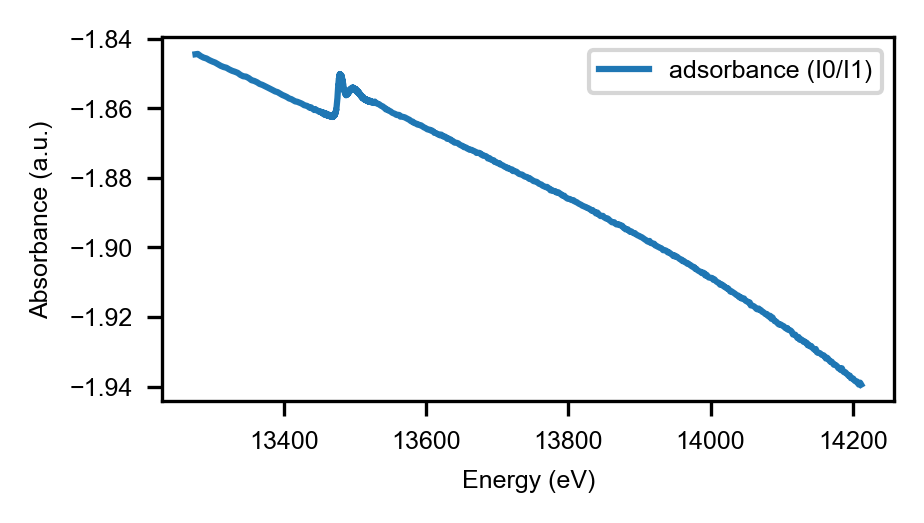

In [13]:
plt.figure(figsize=(8*cm, 4*cm))
# plt.plot(energy, i1, label="I1")
# plt.plot(energy, i0, label="I0")
plt.plot(energy, -np.log(i1/i0), label="adsorbance (I0/I1)")
plt.xlabel("Energy (eV)")
plt.ylabel("Absorbance (a.u.)")
plt.legend()
# plt.yscale("log")
# plt.ylim(1e-3, 1e3)

In [ ]:
total = {}
for i in np.arange(84446, 84466, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    # plot_xas_raw(energy, chs)

    # out = plot_xas_debug(
    #     energy, chs, i0,
    #     pre=(13380, 13420),
    #     norm=(13680, 13780),
    #     post=(13850, 14200),
    #     poly_order=2,
    # )
    out = plot_xas_final(
        energy, chs, i0,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2)
    total[i] = out["mu_flat"]

## mu_E vs Energy

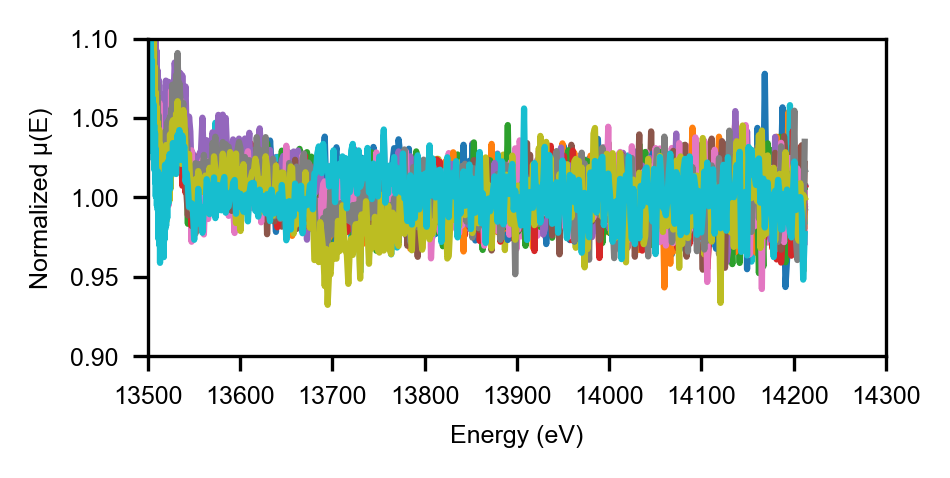

In [6]:
fig, ax = plt.subplots(figsize=(8*cm, 4*cm))
for i in np.arange(84446, 84466, 1):
    plt.plot(energy, total[i], label=f"Scan {i}")

plt.xlim(13500, 14300)
plt.ylim(0.9, 1.1)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized μ(E)")
# plt.legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()

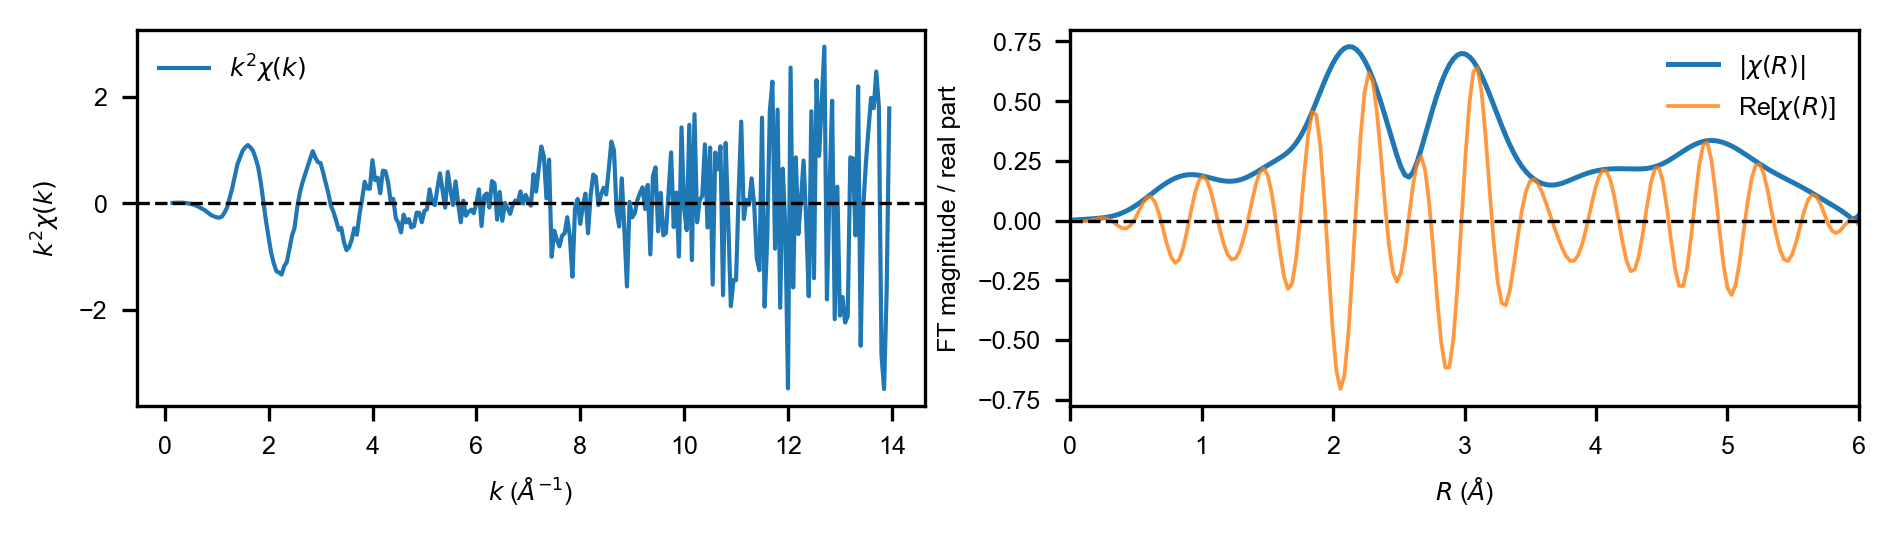

In [8]:
path = "./raw_data/MEX1_84446.mda"
energy, i0, i1, chs = read_spectra_exafs(path)
out_exafs = plot_chi_r(
    energy, i1, chs,
    pre=(13380, 13420),
    norm=(13680, 13780),
    post=(13850, 14200),
    poly_order=2,
    e0=13470,
    kmin=2,
    kmax=12,
    kweight=2,
    background_window=3.0,
    rmax=6.0,
    show_chi_k=True,
)

## EXAFS

In [ ]:
all_exafs = {}
for i in np.arange(84446, 84466, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    out_exafs = plot_chi_r(
        energy, i1, chs,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2,
        e0=13470,
        kmin=2,
        kmax=12,
        kweight=2,
        background_window=3.0,
        rmax=6.0,
        show_chi_k=True,
    )
    all_exafs[i] = out_exafs['r'], out_exafs['chi_r_real'], out_exafs['chi_r_mag']


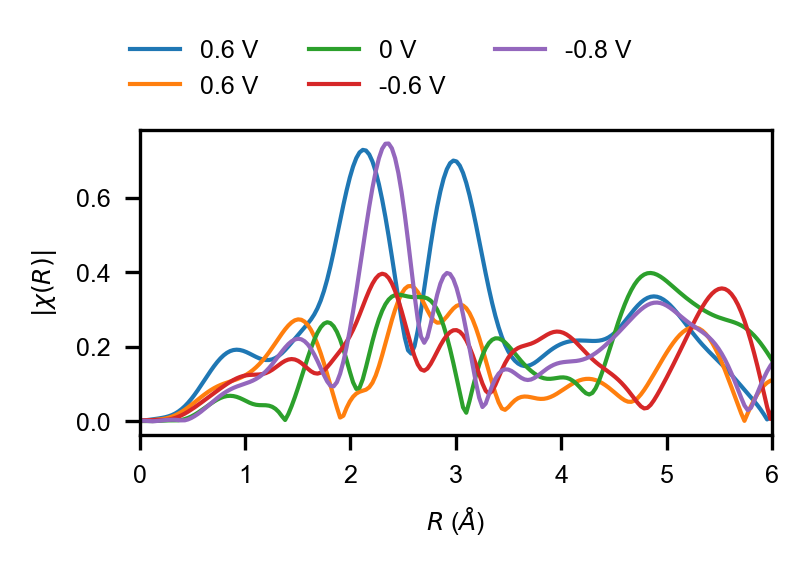

In [17]:
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for i in np.arange(84446, 84465, 4):
    plt.plot(all_exafs[i][0], all_exafs[i][2], label=f"Scan {i}", linewidth=1)

# plt.xlim(13500, 14300)
plt.xlim(0, 6)
ax.set_xlabel(r"$R$ ($\AA$)")
ax.set_ylabel(r"$|\chi(R)|$")
plt.legend(labels=["0.6 V", "0.6 V", "0 V", "-0.6 V", "-0.8 V"], bbox_to_anchor=(-0.05, 1.2), loc='center left', frameon=False, fontsize=6, ncol=3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Bulk ref

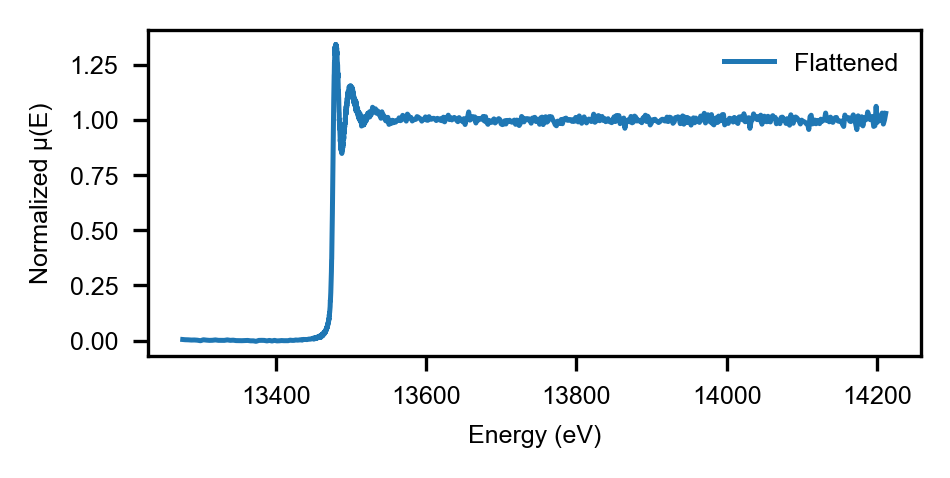

In [18]:
path = "./raw_data/MEX1_84408.mda"
energy, i0, chs = read_spectra(path)

# plot_xas_raw(energy, chs)

# out = plot_xas_debug(
#     energy, chs, i0,
#     pre=(13380, 13420),
#     norm=(13680, 13780),
#     post=(13850, 14200),
#     poly_order=2,
# )
out = plot_xas_final(
    energy, chs, i0,
    pre=(13380, 13420),
    norm=(13680, 13780),
    post=(13850, 14200),
    poly_order=2,)

In [ ]:
total = {}
for i in np.arange(84408, 84414, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    # plot_xas_raw(energy, chs)

    # out = plot_xas_debug(
    #     energy, chs, i0,
    #     pre=(13380, 13420),
    #     norm=(13680, 13780),
    #     post=(13850, 14200),
    #     poly_order=2,
    # )
    out = plot_xas_final(
        energy, chs, i0,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2)
    total[i] = out["mu_flat"]

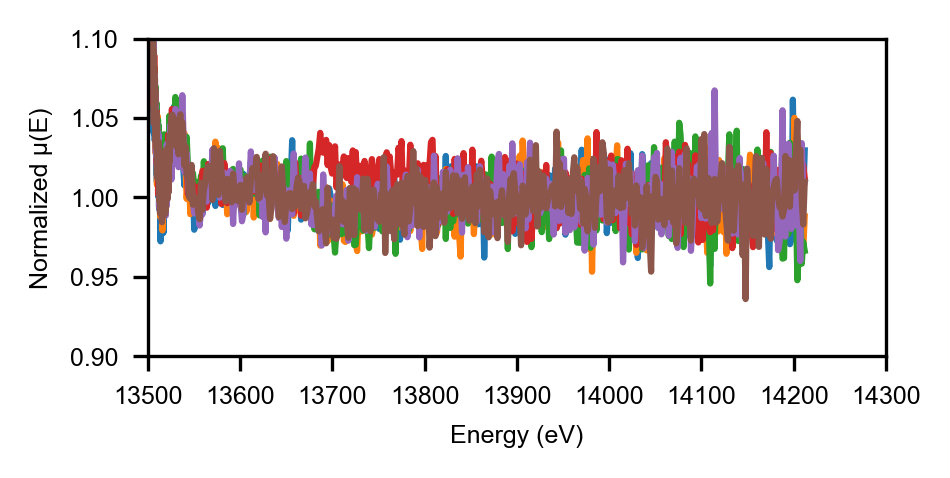

In [20]:
fig, ax = plt.subplots(figsize=(8*cm, 4*cm))
for i in np.arange(84408, 84414, 1):
    plt.plot(energy, total[i], label=f"Scan {i}")

plt.xlim(13500, 14300)
plt.ylim(0.9, 1.1)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized μ(E)")
# plt.legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
all_exafs = {}
for i in np.arange(84408, 84414, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    out_exafs = plot_chi_r(
        energy, i1, chs,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2,
        e0=13470,
        kmin=2,
        kmax=12,
        kweight=2,
        background_window=3.0,
        rmax=6.0,
        show_chi_k=True,
    )
    all_exafs[i] = out_exafs['r'], out_exafs['chi_r_real'], out_exafs['chi_r_mag']


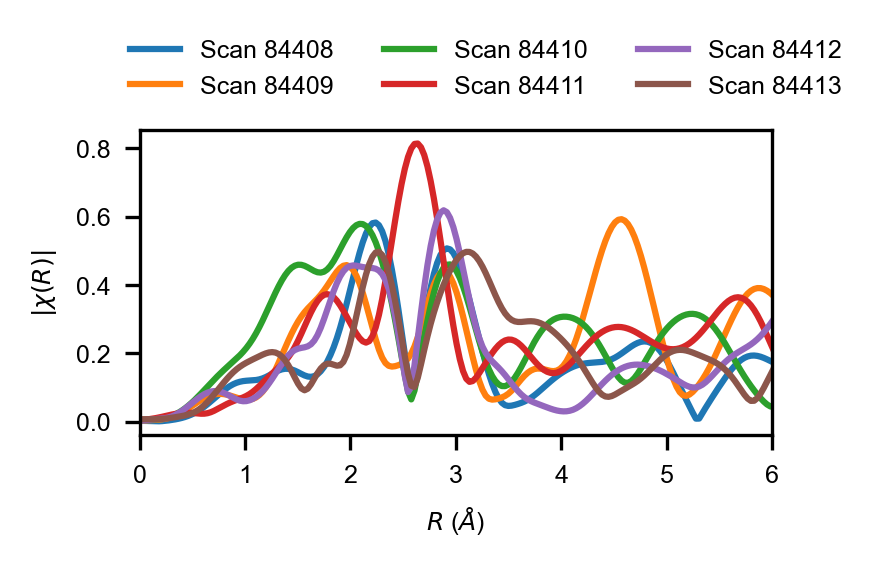

In [23]:
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for i in np.arange(84408, 84414, 1):
    plt.plot(all_exafs[i][0], all_exafs[i][2], label=f"Scan {i}")

# plt.xlim(13500, 14300)
plt.xlim(0, 6)
ax.set_xlabel(r"$R$ ($\AA$)")
ax.set_ylabel(r"$|\chi(R)|$")
plt.legend(bbox_to_anchor=(-0.05, 1.2), loc='center left', frameon=False, fontsize=6, ncol=3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# MGM_0.1 10 mM KBr

In [ ]:
total = {}
for i in np.arange(84546, 84565, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    # plot_xas_raw(energy, chs)

    # out = plot_xas_debug(
    #     energy, chs, i0,
    #     pre=(13380, 13420),
    #     norm=(13680, 13780),
    #     post=(13850, 14200),
    #     poly_order=2,
    # )
    out = plot_xas_final(
        energy, chs, i0,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2)
    total[i] = out["mu_flat"]

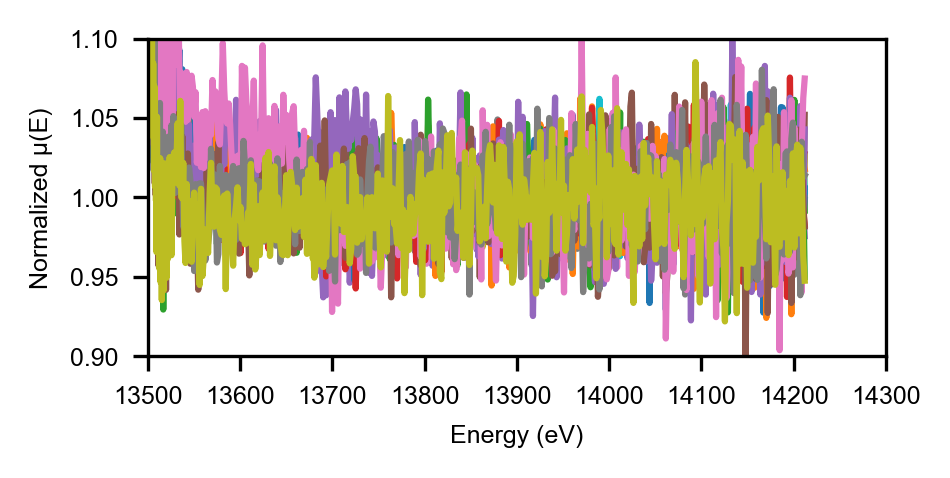

In [25]:
fig, ax = plt.subplots(figsize=(8*cm, 4*cm))
for i in np.arange(84546, 84565, 1):
    plt.plot(energy, total[i], label=f"Scan {i}")

plt.xlim(13500, 14300)
plt.ylim(0.9, 1.1)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized μ(E)")
# plt.legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
all_exafs = {}
for i in np.arange(84546, 84565, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    out_exafs = plot_chi_r(
        energy, i1, chs,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2,
        e0=13470,
        kmin=2,
        kmax=12,
        kweight=2,
        background_window=3.0,
        rmax=6.0,
        show_chi_k=True,
    )
    all_exafs[i] = out_exafs['r'], out_exafs['chi_r_real'], out_exafs['chi_r_mag']


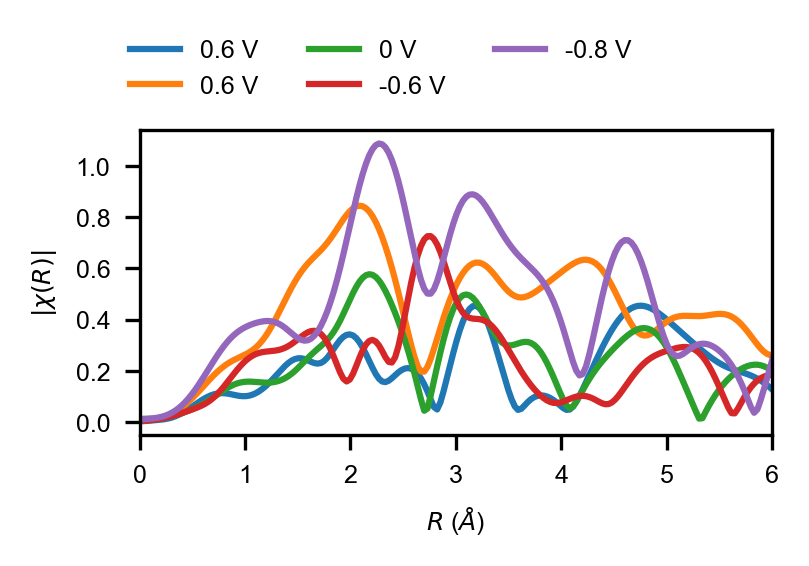

In [30]:
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for i in np.arange(84546, 84565, 4):
    plt.plot(all_exafs[i][0], all_exafs[i][2], label=f"Scan {i}")

# plt.xlim(13500, 14300)
plt.xlim(0, 6)
ax.set_xlabel(r"$R$ ($\AA$)")
ax.set_ylabel(r"$|\chi(R)|$")
plt.legend(labels=["0.6 V", "0.6 V", "0 V", "-0.6 V", "-0.8 V"], bbox_to_anchor=(-0.05, 1.2), loc='center left', frameon=False, fontsize=6, ncol=3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# MGM_0.5 10 mM KBr

In [ ]:
total = {}
for i in np.arange(84596, 84616, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    # plot_xas_raw(energy, chs)

    # out = plot_xas_debug(
    #     energy, chs, i0,
    #     pre=(13380, 13420),
    #     norm=(13680, 13780),
    #     post=(13850, 14200),
    #     poly_order=2,
    # )
    out = plot_xas_final(
        energy, chs, i0,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2)
    total[i] = out["mu_flat"]

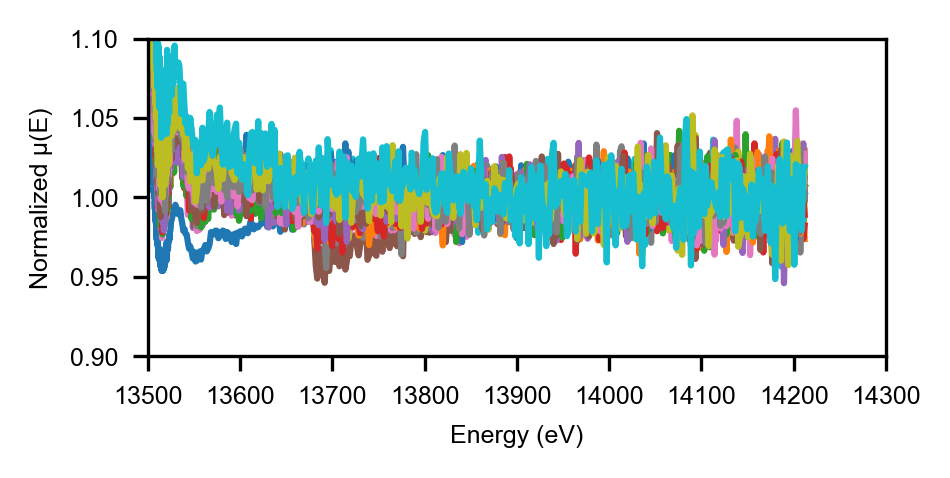

In [32]:
fig, ax = plt.subplots(figsize=(8*cm, 4*cm))
for i in np.arange(84596, 84616, 1):
    plt.plot(energy, total[i], label=f"Scan {i}")

plt.xlim(13500, 14300)
plt.ylim(0.9, 1.1)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized μ(E)")
# plt.legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
all_exafs = {}
for i in np.arange(84596, 84616, 1):
    path = f"./raw_data/MEX1_{i}.mda"
    energy, i0, chs = read_spectra(path)

    out_exafs = plot_chi_r(
        energy, i1, chs,
        pre=(13380, 13420),
        norm=(13680, 13780),
        post=(13850, 14200),
        poly_order=2,
        e0=13470,
        kmin=2,
        kmax=12,
        kweight=2,
        background_window=3.0,
        rmax=6.0,
        show_chi_k=True,
    )
    all_exafs[i] = out_exafs['r'], out_exafs['chi_r_real'], out_exafs['chi_r_mag']


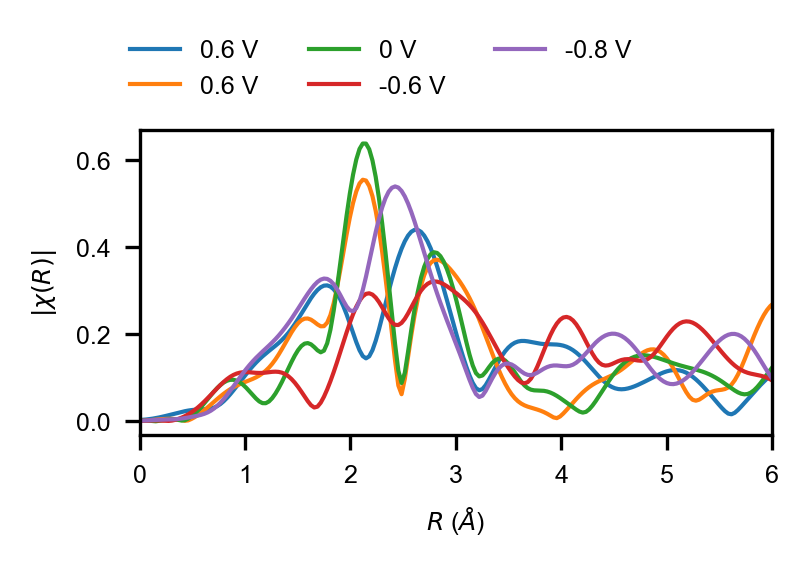

In [35]:
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))
for i in np.arange(84596, 84616, 4):
    plt.plot(all_exafs[i][0], all_exafs[i][2], label=f"Scan {i}", linewidth=1)

# plt.xlim(13500, 14300)
plt.xlim(0, 6)
ax.set_xlabel(r"$R$ ($\AA$)")
ax.set_ylabel(r"$|\chi(R)|$")
plt.legend(labels=["0.6 V", "0.6 V", "0 V", "-0.6 V", "-0.8 V"], bbox_to_anchor=(-0.05, 1.2), loc='center left', frameon=False, fontsize=6, ncol=3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Jeremy plots

In [4]:
import os
import numpy as np
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.dates as mdates
import seaborn as sns
import scipy.signal as sps
from scipy.optimize import leastsq
import scipy.signal as sps
from scipy import integrate
import xraydb
from matplotlib import ticker
import mda
from larch import Group
from larch.io import read_ascii
from larch.xafs import pre_edge
from larch_xas import flatten_transmission_frame

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.default'] = 'it'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
cm = 1 / 2.54

ImportError: cannot import name 'Group' from 'larch' (unknown location)

In [ ]:
# plt.style.use(f"{os.environ['JX']}/jx/jlw.mplstyle")
paulTolHighContrast = ['#33bbee', '#cc3311', '#ee3377', '#0077bb', '#ee7733', '#009988']
sns.set_palette(paulTolHighContrast)

sr570Dict = {
    0 : ('1 pA/V',1.00E+12),
    1 : ('2 pA/V', 5.00E+11),
    2 : ('5 pA/V', 2.00E+11),
    3 : ('10 pA/V', 1.00E+11),
    4 : ('20 pA/V', 5.00E+10),
    5 : ('50 pA/V', 2.00E+10),
    6 : ('100 pA/V', 1.00E+10),
    7 : ('200 pA/V', 5.00E+09),
    8 : ('500 pA/V', 2.00E+09),
    9 : ('1 nA/V', 1.00E+09),
    10 : ('2 nA/V', 5.00E+08),
    11 : ('5 nA/V', 2.00E+08),
    12 : ('10 nA/V', 1.00E+08),
    13 : ('20 nA/V', 5.00E+07),
    14 : ('50 nA/V', 2.00E+07),
    15 : ('100 nA/V', 1.00E+07),
    16 : ('200 nA/V', 5.00E+06),
    17 : ('500 nA/V', 2.00E+06),
    18 : ('1 uA/V', 1.00E+06),
    19 : ('2 uA/V', 5.00E+05),
    20 : ('5 uA/V', 2.00E+05),
    21 : ('10 uA/V', 1.00E+05),
    22 : ('20 uA/V', 5.00E+04),
    23 : ('50 uA/V', 2.00E+04),
    24 : ('100 uA/V', 1.00E+04),
    25 : ('200 uA/V', 5.00E+03),
    26 : ('500 uA/V', 2.00E+03),
    27 : ('1 mA/V', 1.00E+03),
    }


def mdaDetails(theMda):
    '''
    What dimension holds which data?
    Step scans
        0: extra PVs (metadata describing the state of the beamline)
        1: the step scan data
        2: the 4096 energy bin fluoro spectra for each detector element
    Slew scans
        0: extra PVs (metadata describing the state of the beamline)
        1: empty
        2: the slew scan data
        for slew scans, the per-channel fluoro spectra are stored in a hdf5 file with the same scan number in the file name
    '''
    print('This mda has {} dimensions'.format(len(theMda)))
    print('DIMENSION 0 = extraPVs')
    print('There are {} extra PVs'.format(len(theMda[0])))
    print('********************')
    for dim in range(1,len(theMda)):
        print('DIMENSION {} - Positioners'.format(dim))
        if len(theMda[dim].p) == 0:
            print('No positioners for dimension {}'.format(dim))
        else:
            for i in range(0,len(theMda[dim].p)):
                print('positioner {}: {}; shape: {}'.format(i, theMda[dim].p[i].name.decode(), 
                                                           np.shape(theMda[dim].p[i].data)))
        print('DIMENSION {} - Detectors'.format(dim))
        if len(theMda[dim].d) == 0:
            print('No detectors for dimension {}'.format(dim))
        else:
            for i in range(0,len(theMda[dim].d)):
                print('detector {}: {}; shape: {}'.format(i, theMda[dim].d[i].name.decode(), 
                                                                       np.shape(theMda[dim].d[i].data)))
        print('********************')


def openMdaFile(filename, verbose=True):
    try:
        mdaContents = mda.readMDA(filename, useNumpy=True)
    except:
        try:
            print('Failed with rank from file. Forcing maxdim=1')
            mdaContents = mda.readMDA(filename, maxdim=1, useNumpy=True)
        except:
            print('Failed to open mda file')
            mdaContents = None
            pass
        pass
    if verbose == True:
        if len(mdaContents) > 0:
            mdaDetails(mdaContents)
    return mdaContents


def mda2dict(mdaContents, slew=False):
    mdaDict = {}
    if slew is False:
        if mdaContents is not None:
            for i in range(len(mdaContents[1].p)):
                mdaDict[mdaContents[1].p[i].name.decode()] = mdaContents[1].p[i].data
            for i in range(len(mdaContents[1].d)):
                mdaDict[mdaContents[1].d[i].name.decode()] = mdaContents[1].d[i].data
    elif slew is True:
        if mdaContents is not None:
            for i in range(len(mdaContents[2].p)):
                mdaDict[mdaContents[2].p[i].name.decode()] = mdaContents[2].p[i].data[0]
            for i in range(len(mdaContents[2].d)):
                mdaDict[mdaContents[2].d[i].name.decode()] = mdaContents[2].d[i].data[0]        
    return mdaDict


def getMetadata(metadataFilename):
    metadataDf = pd.read_csv(metadataFilename, sep='\t')
    metadataDf = metadataDf.set_index('scan_number', drop=False)
    metadataDf.index.rename('index', inplace=True)
    metadataDf['date'] = pd.to_datetime(metadataDf['timestamp'])
    metadataDf = metadataDf[metadataDf['cancelled'] == False]
    return metadataDf


def getStepData(scanNum, metadataDf):
    filename = metadataDf.at[scanNum, 'filename']
    filename = filename.split('/')[-1]
    filename = f"{theDirectory}/{filename}"
    i0_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch1_dark_current']
    i1_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch2_dark_current']
    i2_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch3_dark_current']
    i0_gain = metadataDf.at[scanNum, 'MEX1ES01AMP01:sens_put']
    i0_gain = sr570Dict[i0_gain][1]
    i1_gain = metadataDf.at[scanNum, 'MEX1ES01AMP02:sens_put']
    i1_gain = sr570Dict[i1_gain][1]
    i2_gain = metadataDf.at[scanNum, 'MEX1ES01AMP03:sens_put']
    i2_gain = sr570Dict[i2_gain][1]
    theMdaData = openMdaFile(filename, verbose=False)
    scanData = mda2dict(theMdaData)
    scanData = pd.DataFrame.from_dict(scanData)
    scanData['ring_current'] = scanData['SR11BCM01:CURRENT_MONITOR']
    scanData['i0_volts'] = scanData['MEX1ES01DAQ01:ch1:S:MeanValue_RBV']
    scanData['i1_volts'] = scanData['MEX1ES01DAQ01:ch2:S:MeanValue_RBV']
    scanData['i2_volts'] = scanData['MEX1ES01DAQ01:ch3:S:MeanValue_RBV']
    scanData['i0_amps'] = (scanData['MEX1ES01DAQ01:ch1:S:MeanValue_RBV']-i0_dark_current)/i0_gain
    scanData['i1_amps'] = (scanData['MEX1ES01DAQ01:ch2:S:MeanValue_RBV']-i1_dark_current)/i1_gain
    scanData['i2_amps'] = (scanData['MEX1ES01DAQ01:ch3:S:MeanValue_RBV']-i2_dark_current)/i2_gain
    scanData['i0_nanoamps'] = scanData['i0_amps'] * 1E9
    scanData['i1_nanoamps'] = scanData['i1_amps'] * 1E9
    scanData['i2_nanoamps'] = scanData['i2_amps'] * 1E9
    scanData['mu_sample'] = np.log(scanData['i0_nanoamps']/scanData['i1_nanoamps'])
    scanData['mu_ref'] = np.log(scanData['i1_nanoamps']/scanData['i2_nanoamps'])
    scanData['energy_eV'] = scanData['MEX1ES01ZEB01:CALC_ENERGY_EV']
    scanData['seconds_in_scan'] = scanData['MEX1ES01GLU01:SECONDS_THIS_MONTH']-scanData['MEX1ES01GLU01:SECONDS_THIS_MONTH'].min()
    scanData['ref_rise'] = np.diff(scanData['mu_ref'], prepend=0)
    scanData['ref_run'] = np.diff(scanData['energy_eV'], prepend=0)
    scanData['ref_deriv'] = np.nan_to_num(scanData['ref_rise']/scanData['ref_run'])
    scanData['smooth_ref_deriv'] = sps.savgol_filter(scanData['ref_deriv'], 7, 3, deriv=0, mode='constant', cval=np.nan)
    scanData['smooth_mu_ref'] = sps.savgol_filter(scanData['mu_ref'], 7, 3, deriv=0, mode='constant', cval=np.nan)
    return scanData


def colMapping(theCol, scanNum, verbose=False):
    if verbose is True:
        print(theCol[:16])
    if theCol[:16] == 'MEX1ES01DAQ01:A:':
        theIndex = theCol.split(":")[2]
        theExtraPV = f"{theCol[:16]}{theIndex}:AttrNameStr"
        if verbose is True:
            print(f'{theCol} is attribute')
            print(f"the index is {theIndex}")
            print(metadataDf[theExtraPV])
        return metadataDf.loc[scanNum][theExtraPV]
    else:
        return None
    

def getSlewData(scanNum, metadataDf):
    filename = f"./raw_data/MEX1_{scanNum}.mda"
    theMdaData = openMdaFile(filename, verbose=False)
    scanData = mda2dict(theMdaData, slew=True)
    scanData = pd.DataFrame.from_dict(scanData)
    
    theCols = list(scanData.columns)
    
    for theCol in theCols:
        mappedCol = colMapping(theCol, scanNum, verbose=False)
        if mappedCol is not None:
            scanData[mappedCol] = scanData[theCol]
    
    theCols = list(scanData.columns)
   
    i0_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch1_dark_current']
    i1_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch2_dark_current']
    i2_dark_current = metadataDf.at[scanNum, 'MEX1ES01DARK01:ch3_dark_current']
    i0_gain = metadataDf.at[scanNum, 'MEX1ES01AMP01:sens_put']
    i0_gain = sr570Dict[i0_gain][1]
    i1_gain = metadataDf.at[scanNum, 'MEX1ES01AMP02:sens_put']
    i1_gain = sr570Dict[i1_gain][1]
    i2_gain = metadataDf.at[scanNum, 'MEX1ES01AMP03:sens_put']
    i2_gain = sr570Dict[i2_gain][1]
    
    iKB_gain = metadataDf.at[scanNum, 'MEX1ES02AMP01:sens_put']
    iKB_gain = sr570Dict[iKB_gain][1]
    iMicro_gain = metadataDf.at[scanNum, 'MEX1ES02AMP02:sens_put']
    iMicro_gain = sr570Dict[iMicro_gain][1]
    
    
    scanData['ring_current'] = scanData['SR11BCM01:CURRENT_MONITOR']
    scanData['BIM_volts'] = scanData['MEX1PDS01DAQ01:N:1:TSMeanValue']
    scanData['i0_volts'] = scanData['MEX1ES01DAQ01:N:1:MeanValue_RBV']
    scanData['i1_volts'] = scanData['MEX1ES01DAQ01:N:2:MeanValue_RBV']
    scanData['i2_volts'] = scanData['MEX1ES01DAQ01:N:3:MeanValue_RBV']
    scanData['i0_volts_cor'] = scanData['i0_volts']-i0_dark_current
    scanData['i1_volts_cor'] = scanData['i1_volts']-i1_dark_current
    scanData['i2_volts_cor'] = scanData['i2_volts']-i2_dark_current
    scanData['i0_nanoamps'] = scanData['i0_volts_cor']/(i0_gain/1E9)
    scanData['i1_nanoamps'] = scanData['i1_volts_cor']/(i1_gain/1E9)
    scanData['i2_nanoamps'] = scanData['i2_volts_cor']/(i2_gain/1E9)
    scanData['mu_sample'] = np.log(scanData['i0_nanoamps']/scanData['i1_nanoamps'])
    scanData['mu_ref'] = np.log(scanData['i1_nanoamps']/scanData['i2_nanoamps'])
    scanData['energy_keV'] = scanData['MEX1DCM01:slew:energyOut']
    scanData['energy_eV'] = scanData['energy_keV']*1000
    
    scanData['ref_rise'] = np.diff(scanData['mu_ref'], prepend=0)
    scanData['ref_run'] = np.diff(scanData['energy_eV'], prepend=0)
    scanData['ref_deriv'] = np.nan_to_num(scanData['ref_rise']/scanData['ref_run'])
    
    if metadataDf.at[scanNum, 'MEX1ES01GLU01:DAQ_MODES'] == 'RTFluoroSlew':
        
        for chan in [1,2,3,4]:
            scanData[f'ch{chan}_counts'] = scanData[f'MEX1ES01DET01:C{chan}SCA:4:TSArrayValue']
            scanData[f'ch{chan}_deadtime_factor'] = scanData[f'MEX1ES01DET01:C{chan}SCA:8:TSArrayValue']
            scanData[f'ch{chan}_dtc_counts'] = scanData[f'ch{chan}_counts'] * scanData[f'ch{chan}_deadtime_factor']
            scanData[f'ch{chan}_realtime'] = scanData[f'MEX1ES01DET01:C{chan}SCA:0:TSArrayValue']/80E6
            scanData[f'ch{chan}_roi_counts'] = scanData[f'MEX1ES01DET01:C{chan}SCA:5:TSArrayValue']
            scanData[f'ch{chan}_cps'] = scanData[f'ch{chan}_counts']/scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_roi_cps'] = scanData[f'ch{chan}_roi_counts']/scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_dtc_roi_counts'] = scanData[f'ch{chan}_roi_counts'] * scanData[f'ch{chan}_deadtime_factor']
            scanData[f'ch{chan}_dtc_cps'] = scanData[f'ch{chan}_dtc_counts'] / scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_dtc_roi_cps'] = scanData[f'ch{chan}_dtc_roi_counts'] / scanData[f'ch{chan}_realtime']
            scanData[f'ch{chan}_icr'] = scanData[f'ch{chan}_dtc_cps']
            scanData[f'ch{chan}_ocr'] = scanData[f'ch{chan}_cps']
            scanData[f'ch{chan}_dtc_roi_cps_i0norm'] = scanData[f'ch{chan}_dtc_roi_cps']/scanData['i0_nanoamps']
            
        scanData['sum_dtc_cps'] = scanData['ch1_dtc_cps'] + scanData['ch2_dtc_cps'] + scanData['ch3_dtc_cps'] + scanData['ch4_dtc_cps']
        scanData['sum_dtc_roi_cps'] = scanData['ch1_dtc_roi_cps'] + scanData['ch2_dtc_roi_cps'] + scanData['ch3_dtc_roi_cps'] + scanData['ch4_dtc_roi_cps']
        
        scanData['mu_fluoro'] = np.mean([scanData['ch1_dtc_roi_cps_i0norm'].values,
                                         scanData['ch2_dtc_roi_cps_i0norm'].values,
                                         scanData['ch3_dtc_roi_cps_i0norm'].values,
                                         scanData['ch4_dtc_roi_cps_i0norm'].values,
                                         ], axis=0)

    return scanData

In [ ]:
# theYear = 2026
# theRound = 1
# theBaseDir = f'./raw_data'
theEPN = "25436"
# # theDirectory = f"{theBaseDir}//{theEPN}"
# # os.chdir('d://tmp//working')
# theDate  = date.today().strftime("%Y%m%d")
metadataDf = getMetadata(f'./raw_data/{theEPN}.metadata')

subsetDf = metadataDf[metadataDf['MEX1ES01GLU01:DAQ_MODES'].isin(['RTFluoroSlew'])]


# pdfFilename = f'{theDate}_{theEPN}_plots.pdf'
# pp = PdfPages(pdfFilename)

scanData = getSlewData(84743, subsetDf)

larch_out = flatten_transmission_frame(
    scanData,
    e0=13470,
    pre1=-90,
    pre2=-50,
    norm1=210,
    norm2=730,
    nnorm=2,
    name='scan_84743',
)

larch_df = pd.DataFrame({
    'energy_eV': larch_out['energy'],
    'mu_trans': larch_out['mu'],
    'mu_norm': larch_out['norm'],
    'mu_flat': larch_out['flat'],
})

cm = 1/2.54  # centimeters in inches
fig, ax = plt.subplots(figsize=(8*cm, 5*cm))

ax.plot(larch_df['energy_eV'], larch_df['mu_trans'], label='Transmission μ(E)', linewidth=0.8)
ax.plot(larch_df['energy_eV'], larch_df['mu_flat'], label='Larch flattened μ(E)', linewidth=1.0)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('μ(E)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"e0 = {larch_out['e0']:.2f} eV")
print(f"edge step = {larch_out['edge_step']:.6f}")
    # scanData['ring_current'] = scanData['SR11BCM01:CURRENT_MONITOR']
    # scanData['BIM_volts'] = scanData['MEX1PDS01DAQ01:N:1:TSMeanValue']
    # scanData['i0_volts'] = scanData['MEX1ES01DAQ01:N:1:MeanValue_RBV']
    # scanData['i1_volts'] = scanData['MEX1ES01DAQ01:N:2:MeanValue_RBV']
    # scanData['i2_volts'] = scanData['MEX1ES01DAQ01:N:3:MeanValue_RBV']
    # scanData['i0_volts_cor'] = scanData['i0_volts']-i0_dark_current
    # scanData['i1_volts_cor'] = scanData['i1_volts']-i1_dark_current
    # scanData['i2_volts_cor'] = scanData['i2_volts']-i2_dark_current
    # scanData['i0_nanoamps'] = scanData['i0_volts_cor']/(i0_gain/1E9)
    # scanData['i1_nanoamps'] = scanData['i1_volts_cor']/(i1_gain/1E9)
    # scanData['i2_nanoamps'] = scanData['i2_volts_cor']/(i2_gain/1E9)
    # scanData['mu_sample'] = np.log(scanData['i0_nanoamps']/scanData['i1_nanoamps'])
    # scanData['mu_ref'] = np.log(scanData['i1_nanoamps']/scanData['i2_nanoamps'])
    # scanData['energy_keV'] = scanData['MEX1DCM01:slew:energyOut']
    # scanData['energy_eV'] = scanData['energy_keV']*1000
    
    # scanData['ref_rise'] = np.diff(scanData['mu_ref'], prepend=0)
    # scanData['ref_run'] = np.diff(scanData['energy_eV'], prepend=0)
    # scanData['ref_deriv'] = np.nan_to_num(scanData['ref_rise']/scanData['ref_run'])


In [ ]:
def makeGroup(scanNum, sampleDict, metadataDf, trim=False, max_energy=None, min_energy=None):
    theGroup = Group()
    sampleDf = pd.DataFrame.from_dict(sampleDict[scanNum])
    windowInUse = metadataDf.at[scanNum, 'window_in_use']
    if max_energy == None:
        max_energy = sampleDf['MEX1ES01ZEB01:CALC_ENERGY_EV'].max()
    if min_energy == None:
        min_energy = sampleDf['MEX1ES01ZEB01:CALC_ENERGY_EV'].min()
    if trim == True:
        sampleDf = sampleDf[sampleDf['MEX1ES01ZEB01:CALC_ENERGY_EV'] <= max_energy]
        sampleDf = sampleDf[sampleDf['MEX1ES01ZEB01:CALC_ENERGY_EV'] >= min_energy]
    theGroup.energy = sampleDf['MEX1ES01ZEB01:CALC_ENERGY_EV']
    theGroup.bragg = sampleDf['MEX1ES01ZEB01:BRAGG_WITH_OFFSET']
    theGroup.trans = sampleDf['muTrans']
    theGroup.fluoro = sampleDf[f'muFluoro_window{int(windowInUse)}']
    theGroup.ref = sampleDf['muRef']
    return theGroup
